TRAINING POLICY
ITERATION 1
ITERATION 2
ITERATION 3
ITERATION 4
ITERATION 5
ITERATION 6
ITERATION 7
ITERATION 8
ITERATION 9
ITERATION 10
ITERATION 11
ITERATION 12
ITERATION 13
ITERATION 14
ITERATION 15
SIMULATION
DAY 1 | P0 | planned=103 | actual=120 | unserved=0 | leftovers=3 | γ_b=0.85 | γ_p=0.9 | cost=49.00
DAY 1 | P1 | planned=150 | actual=134 | unserved=0 | leftovers=19 | γ_b=1.0 | γ_p=1.0 | cost=95.00
DAY 1 | P2 | planned=115 | actual=139 | unserved=5 | leftovers=0 | γ_b=0.85 | γ_p=0.95 | cost=238.00
DAY 1 | P3 | planned=47 | actual=49 | unserved=0 | leftovers=8 | γ_b=0.85 | γ_p=1.0 | cost=50.00
DAY 1 | P4 | planned=74 | actual=71 | unserved=0 | leftovers=11 | γ_b=0.95 | γ_p=0.9 | cost=55.00
DAY 1 | P5 | planned=125 | actual=134 | unserved=0 | leftovers=2 | γ_b=0.95 | γ_p=0.9 | cost=28.00
DAY 1 | P6 | planned=71 | actual=77 | unserved=0 | leftovers=6 | γ_b=0.9 | γ_p=0.95 | cost=44.00
DAY 1 | P7 | planned=125 | actual=123 | unserved=0 | leftovers=8 | γ_b=0.95 | γ_p=0.85 | cost=40.

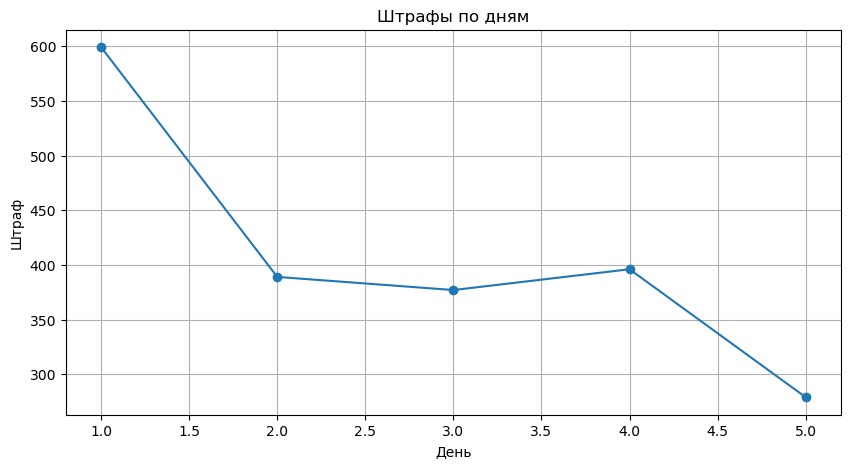

In [1]:

import math
import random
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from copy import deepcopy


# =====================================================
# CONFIG
# =====================================================

INITIAL_C0 = 200

ALPHA = 0.3

LAMBDA_1 = 2.0   # буфер
LAMBDA_2 = 5.0   # остатки
LAMBDA_3 = 8.0   # необслуженные
LAMBDA_4 = 1.0   # доготовка

DISCOUNT = 0.95

OVERBOOKING_LEVELS = [0.80, 0.85, 0.90, 0.95, 1.00]

MC_SAMPLES = 30
VALUE_ITERATIONS = 15

plt.rcParams['font.family'] = 'DejaVu Sans'


# =====================================================
# DATA
# =====================================================

TIME_PERIODS = [
    {"period": 0, "meal_type": "meal_1", "groups": "1, 2 классы", "students_total": 100, "benefit_students": 100},
    {"period": 1, "meal_type": "meal_1", "groups": "3, 4, 5 классы", "students_total": 150, "benefit_students": 128},
    {"period": 2, "meal_type": "meal_1", "groups": "6, 7, 8, 9 классы", "students_total": 200, "benefit_students": 112},
    {"period": 3, "meal_type": "meal_2", "groups": "1 класс", "students_total": 50, "benefit_students": 28},
    {"period": 4, "meal_type": "meal_2", "groups": "2, 3 класс", "students_total": 100, "benefit_students": 56},
    {"period": 5, "meal_type": "meal_2", "groups": "4, 5, 6, 8 классы", "students_total": 200, "benefit_students": 112},
    {"period": 6, "meal_type": "meal_2", "groups": "7, 9 классы", "students_total": 100, "benefit_students": 56},
    {"period": 7, "meal_type": "meal_2", "groups": "школа полного дня", "students_total": 200, "benefit_students": 112},
]


# =====================================================
# STATE
# =====================================================

@dataclass(frozen=True)
class State:
    period: int
    b: int
    lambda_p: int
    c0: int
    buffer: int


@dataclass
class Action:
    gamma_b: float
    gamma_p: float
    cook: int


# =====================================================
# DEMAND
# =====================================================

def sample_absences(b_i):

    d_max = max(1, int(0.15 * b_i))

    weights = [(d_max - d + 1) ** 2 for d in range(d_max + 1)]

    return random.choices(
        list(range(d_max + 1)),
        weights=weights,
        k=1
    )[0]


def poisson_sample(lmbd):

    L = math.exp(-lmbd)

    k = 0
    p = 1

    while p > L:
        k += 1
        p *= random.random()

    return k - 1


def sample_paid(lambda_i):
    return poisson_sample(lambda_i)


def update_lambda(previous_lambda, actual_paid):

    new_lambda = (
        ALPHA * actual_paid
        + (1 - ALPHA) * previous_lambda
    )

    return round(new_lambda)


# =====================================================
# ACTION SPACE
# =====================================================

def generate_actions():

    actions = []

    for gamma_b in OVERBOOKING_LEVELS:
        for gamma_p in OVERBOOKING_LEVELS:
            for cook in [0, 10, 20]:

                actions.append(
                    Action(
                        gamma_b=gamma_b,
                        gamma_p=gamma_p,
                        cook=cook
                    )
                )

    return actions


ALL_ACTIONS = generate_actions()


# =====================================================
# TRANSITION
# =====================================================

def transition(state, action):

    prep_b = round(state.b * action.gamma_b)
    prep_p = round(state.lambda_p * action.gamma_p)

    planned = prep_b + prep_p

    d = sample_absences(state.b)

    w = sample_paid(state.lambda_p)

    actual_benefit = state.b - d

    actual = actual_benefit + w

    available = planned + state.buffer + action.cook

    served = min(actual, available)

    unserved = max(0, actual - available)

    used_buffer = min(
        state.buffer,
        max(0, actual - planned)
    )

    leftovers = max(0, available - actual)

    next_period = (state.period + 1) % len(TIME_PERIODS)

    next_lambda = update_lambda(
        state.lambda_p,
        w
    )

    next_buffer = min(80, leftovers)

    next_state = State(
        period=next_period,
        b=TIME_PERIODS[next_period]["benefit_students"],
        lambda_p=next_lambda,
        c0=max(0, state.c0 - action.cook),
        buffer=next_buffer
    )

    cost = (
        LAMBDA_1 * used_buffer
        + LAMBDA_2 * leftovers
        + LAMBDA_3 * (unserved ** 2)
        + LAMBDA_4 * action.cook
    )

    info = {
        "planned": planned,
        "actual": actual,
        "served": served,
        "unserved": unserved,
        "leftovers": leftovers,
        "cost": cost,
        "gamma_b": action.gamma_b,
        "gamma_p": action.gamma_p,
    }

    return next_state, cost, info


# =====================================================
# BELLMAN
# =====================================================

V = {}
POLICY = {}


def get_value(state):

    if state not in V:
        V[state] = 0.0

    return V[state]


def bellman_update(state):

    best_value = float("inf")

    best_action = None

    for action in ALL_ACTIONS:

        total = 0

        for _ in range(MC_SAMPLES):

            next_state, cost, _ = transition(
                state,
                action
            )

            total += (
                cost
                + DISCOUNT * get_value(next_state)
            )

        expected = total / MC_SAMPLES

        if expected < best_value:

            best_value = expected

            best_action = action

    return best_value, best_action


# =====================================================
# VALUE ITERATION
# =====================================================

def train_policy():

    states = []

    for period in range(len(TIME_PERIODS)):

        for lambda_p in range(0, 41, 5):

            for buffer in range(0, 81, 10):

                s = State(
                    period=period,
                    b=TIME_PERIODS[period]["benefit_students"],
                    lambda_p=lambda_p,
                    c0=INITIAL_C0,
                    buffer=buffer
                )

                states.append(s)

    for iteration in range(VALUE_ITERATIONS):

        print(f"ITERATION {iteration+1}")

        new_V = {}

        for state in states:

            value, action = bellman_update(state)

            new_V[state] = value

            POLICY[state] = action

        V.update(new_V)


# =====================================================
# POLICY
# =====================================================

def optimal_policy(state):

    key = State(
        period=state.period,
        b=state.b,
        lambda_p=5 * round(state.lambda_p / 5),
        c0=INITIAL_C0,
        buffer=10 * round(state.buffer / 10)
    )

    if key in POLICY:
        return POLICY[key]

    return Action(1.0, 1.0, 0)


# =====================================================
# SIMULATION
# =====================================================

def simulate_days(num_days):

    results = []

    state = State(
        period=0,
        b=TIME_PERIODS[0]["benefit_students"],
        lambda_p=20,
        c0=INITIAL_C0,
        buffer=20
    )

    cumulative_cost = 0

    for day in range(num_days):

        for period in range(len(TIME_PERIODS)):

            action = optimal_policy(state)

            next_state, cost, info = transition(
                state,
                action
            )

            cumulative_cost += cost

            results.append({
                "day": day + 1,
                "period": period,
                "meal_type": TIME_PERIODS[period]["meal_type"],
                "groups": TIME_PERIODS[period]["groups"],
                "planned": info["planned"],
                "actual": info["actual"],
                "served": info["served"],
                "unserved": info["unserved"],
                "leftovers": info["leftovers"],
                "cost": cost,
                "gamma_b": info["gamma_b"],
                "gamma_p": info["gamma_p"],
                "cumulative_cost": cumulative_cost
            })

            state = next_state

    return results


# =====================================================
# PLOTS
# =====================================================

def plot_results(results):

    days = sorted(list(set(r["day"] for r in results)))

    daily_costs = []

    for day in days:

        day_cost = sum(
            r["cost"]
            for r in results
            if r["day"] == day
        )

        daily_costs.append(day_cost)

    plt.figure(figsize=(10, 5))

    plt.plot(days, daily_costs, marker='o')

    plt.xlabel("День")

    plt.ylabel("Штраф")

    plt.title("Штрафы по дням")

    plt.grid(True)

    plt.show()


# =====================================================
# MAIN
# =====================================================

def main():

    random.seed(42)

    print("=" * 60)

    print("TRAINING POLICY")

    print("=" * 60)

    train_policy()

    print("=" * 60)

    print("SIMULATION")

    print("=" * 60)

    results = simulate_days(5)

    for r in results:

        print(
            f"DAY {r['day']} | "
            f"P{r['period']} | "
            f"planned={r['planned']} | "
            f"actual={r['actual']} | "
            f"unserved={r['unserved']} | "
            f"leftovers={r['leftovers']} | "
            f"γ_b={r['gamma_b']} | "
            f"γ_p={r['gamma_p']} | "
            f"cost={r['cost']:.2f}"
        )

    total = sum(r["cost"] for r in results)

    print("\nTOTAL COST:", round(total, 2))

    plot_results(results)


if __name__ == "__main__":
    main()

